# 🦖 Dinoszaurusz Adathalmaz Elemzése és Modellezése

## 📚 Adatforrás és Hivatkozás
Az elemzéshez felhasznált adathalmaz a **Kaggle** platformról származik, amely a nemzetközi **Paleobiology Database (PBDB)** nyilvános fosszília-nyilvántartásán alapul.

- **Adathalmaz címe:** Dinosaur Dataset
- **Készítő / Feltöltő:** Smruthi Ramesh (Kaggle)
- **Elérhetőség:** [Kaggle - Dinosaur Dataset](https://www.kaggle.com/datasets/smruthiiii/dinosaur-dataset)
- **Eredeti primer adatforrás:** [The Paleobiology Database](https://paleobiodb.org/)
- **Letöltés dátuma:** 2026. szeptember 23.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os



In [ ]:
df = pd.read_csv("data/dinosaurs.csv")

df.shape

(4951, 12)

In [9]:
df.head()

,occurrence_no,name,diet,type,length_m,max_ma,min_ma,region,lng,lat,class,family
0,130294,Protarchaeopteryx,omnivorous,small theropod,2.0,130.0,122.46,Liaoning,120.733330,41.799999,Saurischia,Archaeopterygidae
1,130295,Caudipteryx,omnivorous,small theropod,1.0,130.0,122.46,Liaoning,120.733330,41.799999,Saurischia,Caudipterygidae
2,139242,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.528732,50.740726,Saurischia,Tyrannosauridae
3,139250,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.549347,50.737015,Saurischia,Tyrannosauridae
4,139252,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.564636,50.723866,Saurischia,Tyrannosauridae


In [13]:
pd.notnull(df).sum()

occurrence_no    4951
name             4951
diet             3596
type             3596
length_m         3568
max_ma           4951
min_ma           4951
region           4909
lng              4951
lat              4951
class            4951
family           3494
dtype: int64

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4951 entries, 0 to 4950
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   occurrence_no  4951 non-null   int64  
 1   name           4951 non-null   str    
 2   diet           3596 non-null   str    
 3   type           3596 non-null   str    
 4   length_m       3568 non-null   float64
 5   max_ma         4951 non-null   float64
 6   min_ma         4951 non-null   float64
 7   region         4909 non-null   str    
 8   lng            4951 non-null   float64
 9   lat            4951 non-null   float64
 10  class          4951 non-null   str    
 11  family         3494 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 464.3 KB


In [19]:
df.describe()

,occurrence_no,length_m,max_ma,min_ma,lng,lat
count,4.951000e+03,3568.000000,4951.000000,4951.000000,4951.000000,4951.000000
mean,6.838323e+05,8.212688,117.518477,106.622270,-37.048675,34.591448
std,3.021524e+05,6.629887,45.270821,44.395885,84.591106,23.961138
min,1.302090e+05,0.450000,70.600000,66.000000,-153.247498,-84.333336
25%,4.871225e+05,3.000000,83.500000,70.600000,-108.258705,36.274439
50%,5.618050e+05,6.700000,99.600000,89.800000,-96.099998,42.611198
75%,8.675665e+05,10.000000,155.700000,145.000000,27.383331,47.745138
max,1.365954e+06,35.000000,252.170000,247.200000,565.000000,78.101875


In [21]:
df['diet'].value_counts()

diet
herbivorous    2076
carnivorous    1308
omnivorous      212
Name: count, dtype: int64

In [23]:
df['type'].value_counts()

type
ornithopod          811
large theropod      733
small theropod      717
sauropod            665
ceratopsian         363
armored dinosaur    307
Name: count, dtype: int64

In [22]:
df['lng'].max()

np.float64(565.0)

# 1. Fejezet: Adathalmaz áttekintése és a modellezési célok kitűzése

Az adathalmaz összesen **4951 sorból** és **12 oszlopból** áll.

### Az adathalmaz fontosabb oszlopai:

| Oszlopnév | Típus | Leírás |
| :--- | :---: | :--- |
| `name` | Szöveges | A dinoszaurusz nemzetség / faj neve |
| `diet` | Szöveges | Étrend (*herbivorous*, *carnivorous*, *omnivorous*) |
| `type` | Szöveges | Mozgás és morfológiai csoport (pl. *large theropod*, *sauropod*) |
| `length_m` | Numerikus | Becsült testhossz méterben kifejezve |
| `max_ma` | Numerikus | A lelet maximális kora (millió évvel ezelőtt) |
| `min_ma` | Numerikus | A lelet minimális kora (millió évvel ezelőtt) |

> **További oszlopok szerepe:**
> * `occurrence_no`: A Paleobiology Database lelet-azonosító sorszáma; modellezéshez nem hordoz érdemi információt, így a tisztításkor elvetjük.
> * `region`, `lng`, `lat`: Földrajzi lelőhely és koordináták.
> * `class`, `family`: Magasabb szintű rendszertani besorolások.

---

### Adathalmaz sajátosságok és anomáliák:
* **Földrajzi koordináta hiba:** A földrajzi hosszúság (`lng`) elméleti határértéke -180° és +180° között mozoghat, az adathalmazban azonban előfordul hibás mérésként **565.0** is, amit szűrni szükséges.
* **Kiugró értékek (outlierek):** A testhossz (`length_m`) minimuma 0.45 m, mediánja 6.7 m, míg maximuma eléri a 35 m-t. Ez jelentős jobb oldali ferdeséget és extrém kiugró értékeket mutat a szauropodák mérete miatt.

---

### Modellezési feladat (Gépi tanulási cél):
* **Feladat jellege:** Felügyelt többosztályos osztályozás (Multi-class Classification).
* **Célváltozó ($y$):** `diet` (étrend: növényevő, húsevő, mindenevő).
* **Bemeneti jellemzők ($X$):** Testhossz (`length_m`), típus (`type`), valamint a földtörténeti kor (`max_ma`, `min_ma`).
* **Cél:** Annak vizsgálata, hogy a dinoszauruszok morfológiai és kormeghatározási adatai alapján megbízhatóan előrejelezhető-e a táplálkozási típusuk.

---

### Feltehető hipotézisek:
* **H1 (Méretkülönbség az étrend szerint):** A növényevő dinoszauruszok átlagos testhossza szignifikánsan nagyobb-e, mint a húsevőké?
* **H2 (Korszakok szerinti méretnövekedés):** A kréta korban (fiatalabb kőzetrétegek) élt theropodák átlagos mérete nagyobb volt-e, mint a jura koriaké?

testhossz (length_m) eloszlása

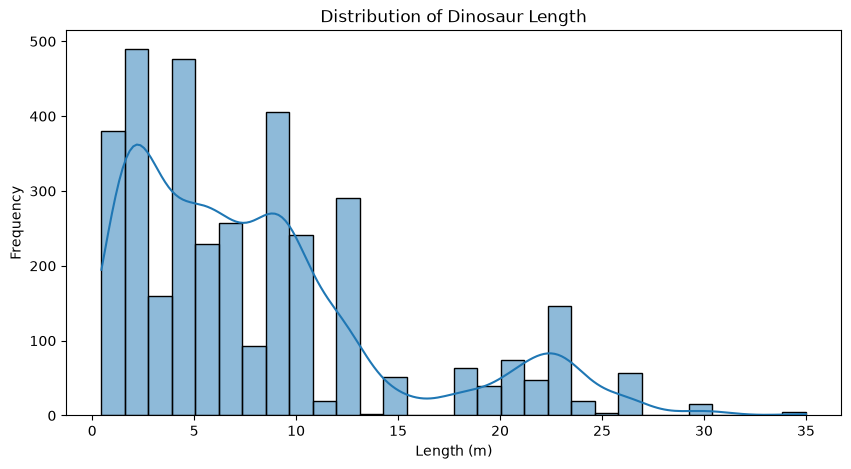

In [25]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='length_m', bins=30, kde=True)
plt.title('Distribution of Dinosaur Length')
plt.xlabel('Length (m)')
plt.ylabel('Frequency')
plt.show()

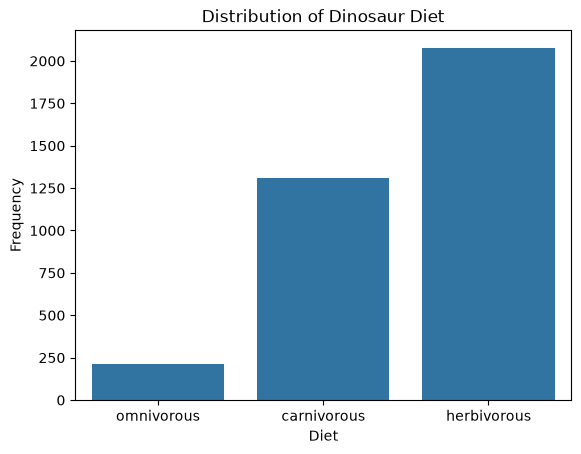

In [ ]:
sns.countplot(data=df, x='diet')
plt.title('Distribution of Dinosaur Diet')
plt.xlabel('Diet')
plt.ylabel('Frequency')

plt.show()

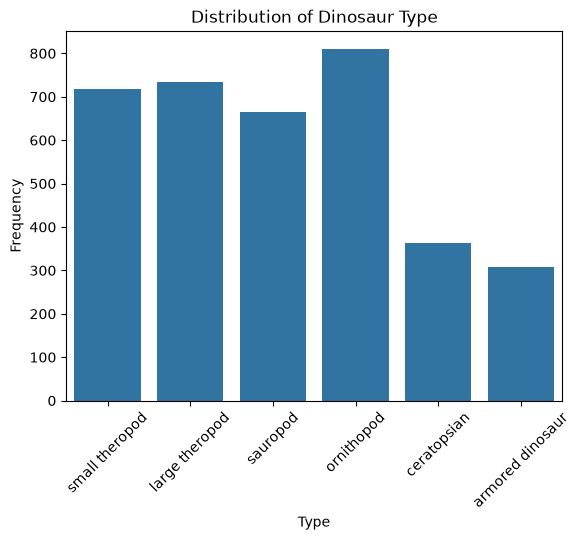

In [30]:
sns.countplot(data=df, x='type' )
plt.title('Distribution of Dinosaur Type')
plt.xlabel('Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.show()

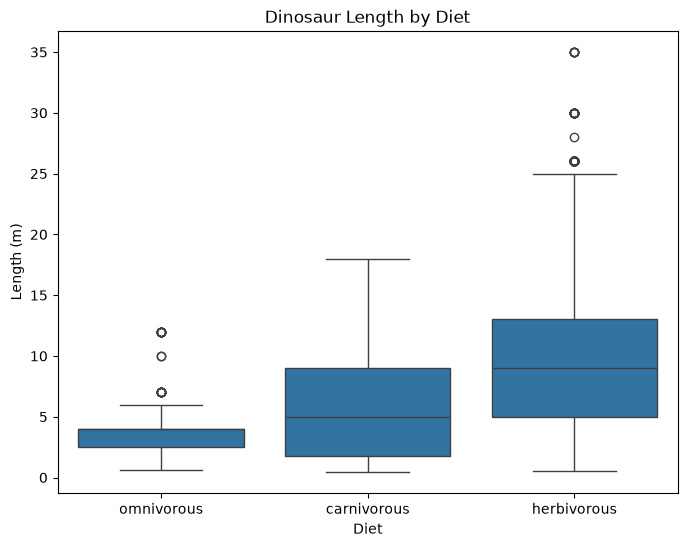

In [32]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='diet', y='length_m')
plt.title('Dinosaur Length by Diet')
plt.xlabel('Diet')
plt.ylabel('Length (m)')
plt.show()

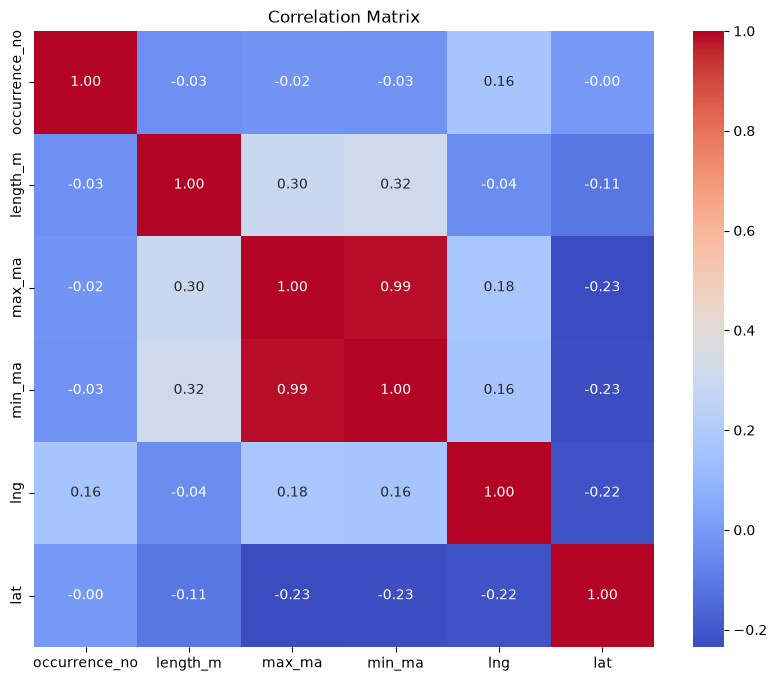

In [33]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# 2. Fejezet: Felfedező Adatelemzés (EDA) és Vizualizáció

### Főbb megfigyelések és következtetések:

1. **Testhossz eloszlása (`length_m`):**
   - Erősen jobbra ferde eloszlás jellemzi: a legtöbb dinoszaurusz mérete 1 és 10 méter között mozog, a sűrűségi csúcs 2–3 méternél található.
   - 20–25 méter környékén megjelenik egy kisebb másodlagos púp, ami a különösen nagy testű szauropodák jelenlétére utal.

2. **Kategóriás változók arányai:**
   - A célváltozónál (`diet`) osztály-kiegyensúlyozatlanság figyelhető meg: a növényevők többségben vannak, míg a mindenevők aránya alacsony. Emiatt a modellezés kiértékelésénél a pontosság mellett a súlyozott F1-score lesz mérvadó.
   - A típusok (`type`) megoszlása viszonylag kiegyensúlyozott, a theropodák és szauropodák egyaránt magas mintaszámmal rendelkeznek.

3. **Méret és étrend kapcsolata (Boxplot elemzés):**
   - A növényevők medián mérete (~9 m) szembetűnően magasabb a húsevőkénél (~5 m) és a mindenevőkénél (~3.5 m).
   - A legnagyobb kiugró értékek (25–35 m) kizárólag a növényevők csoportjában fordulnak elő, ami alátámasztja a H1 hipotézist.

4. **Korrelációs vizsgálatok (Heatmap):**
   - A `max_ma` és `min_ma` között extrém magas korreláció (r = 0.99) áll fenn (multikollinearitás), ezért a modellezéshez célszerűbb lesz egy származtatott változót használni.
   - Az `occurrence_no` semmilyen érdemi összefüggést nem mutat a fizikai jellemzőkkel, így igazoltan eldobható adat.